In [43]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV

import librosa, librosa.display
import IPython.display as ipd



plt.rcParams['figure.figsize'] = (10, 3)

In [44]:
pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


# Phân loại dựa trên các đặc trưng đã có sẵn

## Tập Huấn luyện (Train Set)

In [45]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

db_config = {
    "host": "127.0.0.1",
    "user": "root",
    "password": quote_plus("22092005@Dung"),
    "database": "music_db",
    "port": 3306
}

engine = create_engine(
    f"mysql+pymysql://{db_config['user']}:{db_config['password']}@"
    f"{db_config['host']}:{db_config['port']}/{db_config['database']}"
)

try:
    query = "SELECT * FROM songs_features"

    features_30_sec = pd.read_sql(
        query,
        con=engine
    )

    data_each_song = features_30_sec

    print("✅ Đã kết nối MySQL và tải dữ liệu thành công!")

    print(features_30_sec.head())

except Exception as e:
    print(f"❌ Lỗi kết nối MySQL: {e}")

✅ Đã kết nối MySQL và tải dữ liệu thành công!
      filename  length  chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0  blues.00000  661500          0.349951         0.088752  0.130192  0.002830   
1  blues.00001  661500          0.340945         0.094968  0.095892  0.002374   
2  blues.00002  661500          0.363562         0.085277  0.175494  0.002753   
3  blues.00003  661500          0.404848         0.094018  0.141139  0.006340   
4  blues.00004  661500          0.308598         0.087850  0.091540  0.002305   

   spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0             1784.416546          129739.837273              2002.657106   
1             1529.871314          376011.650353              2038.612143   
2             1552.637786          156538.294605              1747.382028   
3             1070.110059          184506.655476              1596.244204   
4             1835.507008          343334.237032              1748.367477   

   s

Chia các bài hát thành tập huấn luyện (train) và tập kiểm tra (test) sử dụng bộ dữ liệu bản 30 giây

In [46]:
# CHỮA LỖI: Đổi từ 'label' thành 'genre_label' cho khớp với file CSV của bạn
X = data_each_song.drop(columns=['genre_label'])
labels = data_each_song.loc[:, 'genre_label']

cat_y = pd.Categorical(labels)
y = pd.Series(cat_y.codes)

print("✅ Đã chia tách X và y thành công!")
print(f"Kích thước tập dữ liệu số X: {X.shape}")

✅ Đã chia tách X và y thành công!
Kích thước tập dữ liệu số X: (990, 62)


In [47]:
# train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=123)

In [48]:
# songs to train
fn_train = np.sort(X_train.filename.values)

# songs to test
fn_test = np.sort(X_test.filename.values)

Chia 3 giây

In [49]:
data = features_30_sec

In [50]:
# 1. Tách chuỗi theo dấu chấm trực tiếp trên toàn bộ cột (Cực nhanh và an toàn)
split_columns = data['filename'].astype(str).str.split('.')

# 2. Ghép phần tử đầu tiên (thể loại) và phần tử thứ hai (mã số) lại với nhau
# .str[0] lấy chữ đứng trước dấu chấm đầu tiên, .str[1] lấy mã số
data['songname'] = split_columns.str[0] + '.' + split_columns.str[1]

print("✅ Đã tạo cột 'songname' cho bản 30s thành công (Đã triệt tiêu hoàn toàn IndexError)!")
print("-" * 60)
print(data['songname'].head())  # In thử 5 dòng đầu xem chuẩn đét chưa nha

✅ Đã tạo cột 'songname' cho bản 30s thành công (Đã triệt tiêu hoàn toàn IndexError)!
------------------------------------------------------------
0    blues.00000
1    blues.00001
2    blues.00002
3    blues.00003
4    blues.00004
Name: songname, dtype: object


In [51]:
song_data_ = []
for song in fn_train:
    song_data_.append(data[data.songname==song])
train_data = pd.concat(song_data_)

song_data_ = []
for song in fn_test:
    song_data_.append(data[data.songname==song])
test_data = pd.concat(song_data_)

In [52]:
X_train = train_data.select_dtypes(include=['number']).drop(columns=['length'], errors='ignore')
y_train = pd.Series(pd.Categorical(train_data.loc[:, 'genre_label']).codes)

X_test = test_data.select_dtypes(include=['number']).drop(columns=['length'], errors='ignore')
y_test = pd.Series(pd.Categorical(test_data.loc[:, 'genre_label']).codes)

print("✅ Đã sửa cách lấy cột đặc trưng thành công!")
print(f"Kích thước X_train thực tế: {X_train.shape[0]} hàng, {X_train.shape[1]} cột.")

✅ Đã sửa cách lấy cột đặc trưng thành công!
Kích thước X_train thực tế: 693 hàng, 59 cột.


In [53]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

In [54]:
y_train.value_counts()

4    76
0    72
5    72
6    72
1    71
7    70
8    69
2    68
9    65
3    58
Name: count, dtype: int64

In [55]:
y_test.value_counts()

3    41
9    34
2    32
8    30
7    29
1    28
0    27
6    27
5    26
4    23
Name: count, dtype: int64

## Model

In [56]:
svc = SVC(kernel='rbf')
rf = RandomForestClassifier()
# clf = AdaBoostClassifier()
# clf = GradientBoostingClassifier()
xgb = XGBClassifier(n_estimators=100)

**Hyperparameter tuning**

In [57]:
param_grid1 = {'C': [10, 100], 
              'gamma': [0.1, 0.01, 0.001]} 
cv = StratifiedKFold(n_splits=3, shuffle=True)  
grid1 = GridSearchCV(svc, param_grid1, cv=cv, verbose = 1)
grid1.fit(X_train_scaled, y_train)
print(grid1.best_estimator_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
SVC(C=100, gamma=0.01)


In [58]:
param_grid2 = {'n_estimators': [50, 100],
               'max_depth': [None, 6, 12]}
cv = StratifiedKFold(n_splits=3, shuffle=True)
grid2 = GridSearchCV(rf, param_grid2, cv=cv, verbose = 1)
grid2.fit(X_train, y_train)
print(grid2.best_estimator_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
RandomForestClassifier()


In [59]:
param_grid3 = {'learning_rate': [0.01, 0.1, 0.3, 0.5]}
cv = StratifiedKFold(n_splits=3, shuffle=True)
grid3 = GridSearchCV(xgb, param_grid3, cv=cv, verbose = 1)
grid3.fit(X_train, y_train)
print(grid3.best_estimator_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


**train**

In [60]:
clf1 = grid1.best_estimator_
clf1.fit(X_train_scaled, y_train)

clf2 = grid2.best_estimator_
clf2.fit(X_train, y_train)

clf3 = grid3.best_estimator_
clf3.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

**predict**

In [61]:
# for SVC
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [62]:
y_true = y_test.copy()
y_pred1 = clf1.predict(X_test_scaled) # SVC
y_pred2 = clf2.predict(X_test)
y_pred3 = clf3.predict(X_test)

## Results

SVM Accuracy:  0.7104377104377104
SVM F1:  0.7136856678930933


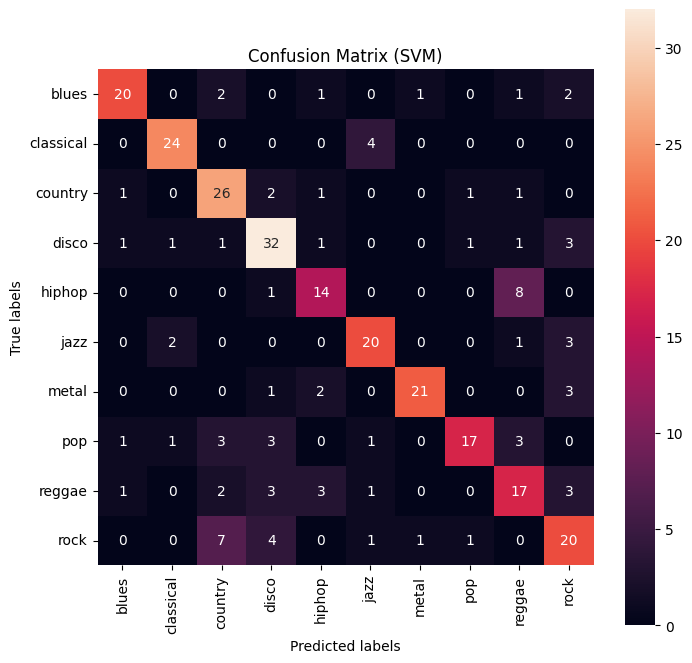

In [63]:
print('SVM Accuracy: ', accuracy_score(y_true, y_pred1))
print('SVM F1: ', f1_score(y_true, y_pred1, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred1), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (SVM)')
plt.show()

In [64]:
print("SVC classification report:",'\n')
print(classification_report(y_true, y_pred1))
print(dict(zip(cat_y.categories, range(10))))

SVC classification report: 

              precision    recall  f1-score   support

           0       0.83      0.74      0.78        27
           1       0.86      0.86      0.86        28
           2       0.63      0.81      0.71        32
           3       0.70      0.78      0.74        41
           4       0.64      0.61      0.62        23
           5       0.74      0.77      0.75        26
           6       0.91      0.78      0.84        27
           7       0.85      0.59      0.69        29
           8       0.53      0.57      0.55        30
           9       0.59      0.59      0.59        34

    accuracy                           0.71       297
   macro avg       0.73      0.71      0.71       297
weighted avg       0.72      0.71      0.71       297

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


RF Accuracy:  0.6531986531986532
RF F1:  0.6605554735494454


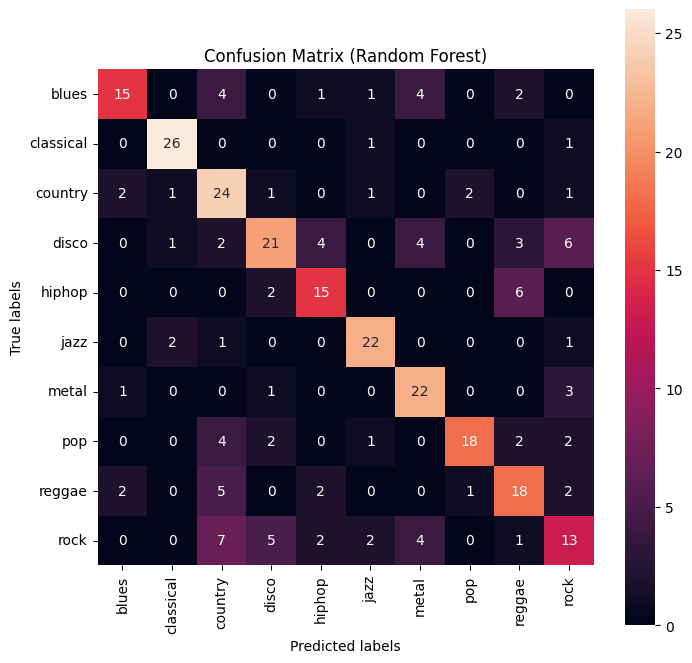

In [65]:
print('RF Accuracy: ', accuracy_score(y_true, y_pred2))
print('RF F1: ', f1_score(y_true, y_pred2, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred2), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (Random Forest)')
plt.show()

In [66]:
print("RF classification report:",'\n')
print(classification_report(y_true, y_pred2))
print(dict(zip(cat_y.categories, range(10))))

RF classification report: 

              precision    recall  f1-score   support

           0       0.75      0.56      0.64        27
           1       0.87      0.93      0.90        28
           2       0.51      0.75      0.61        32
           3       0.66      0.51      0.58        41
           4       0.62      0.65      0.64        23
           5       0.79      0.85      0.81        26
           6       0.65      0.81      0.72        27
           7       0.86      0.62      0.72        29
           8       0.56      0.60      0.58        30
           9       0.45      0.38      0.41        34

    accuracy                           0.65       297
   macro avg       0.67      0.67      0.66       297
weighted avg       0.66      0.65      0.65       297

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


XGB Accuracy:  0.6632996632996633
XGB F1:  0.6735801982508173


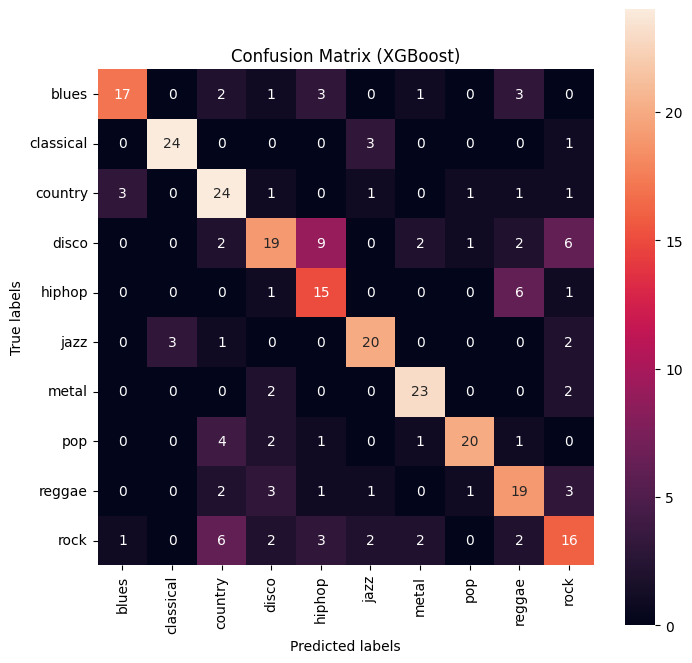

In [67]:
print('XGB Accuracy: ', accuracy_score(y_true, y_pred3))
print('XGB F1: ', f1_score(y_true, y_pred3, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred3), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (XGBoost)')
plt.show()

In [68]:
print("XGB classification report:",'\n')
print(classification_report(y_true, y_pred3))
print(dict(zip(cat_y.categories, range(10))))

XGB classification report: 

              precision    recall  f1-score   support

           0       0.81      0.63      0.71        27
           1       0.89      0.86      0.87        28
           2       0.59      0.75      0.66        32
           3       0.61      0.46      0.53        41
           4       0.47      0.65      0.55        23
           5       0.74      0.77      0.75        26
           6       0.79      0.85      0.82        27
           7       0.87      0.69      0.77        29
           8       0.56      0.63      0.59        30
           9       0.50      0.47      0.48        34

    accuracy                           0.66       297
   macro avg       0.68      0.68      0.67       297
weighted avg       0.68      0.66      0.66       297

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


## interpretation

- As a result of checking the performance of the classifier by targeting the genre for 3 seconds(1/10 part) of each song, it can be seen that the accuracy and F1 score are about 69%. XGboost shows highest performace scores among the models

- As you can see in the confusion matrix some specific genres are misclassified. Let's check this case by case.

- First of all, let's look at which genre was most mis-predicted for each genre. (RF based)
     - **Blues**: Country 31, Metal 23, etc.
     - **Classical** (high score - well classified): Jazz 12
     - **Country**: Blues 35, Rock 18, etc.
     - **Disco**: Hip Hop 55, Metal 31, Rock 31, etc.
     - **Hip Hop**: Pop 32, Reggae 19
     - **Jazz**: Classic 23
     - **Metal**: Blues 17, Rock 14, etc.
     - **Pop**: Hip Hop 30, Disco 17, etc.
     - **Reggae**: Country 24, Hip Hop 23, etc.
     - **Rock** (low score): Metal 69, Disco 4, etc.
    
- Looking at the misclassified genres, we can see the pairs: **blues-country, classical-jazz, disco-hip-hop, pop-hip-hop, hip-hop-reggae, metal-rock**. Intuitively, it is mainly genre pairs that are generally thought to have genre similarities (but there are some pairs that are not; **metal-blues, raggae-country**; maybe they have some similar musical characteristics)

- In other words, it can be inferred that the feature based on the given audio content has some musical characteristic information, similar to the genre artificially classified by people.

## feature importance

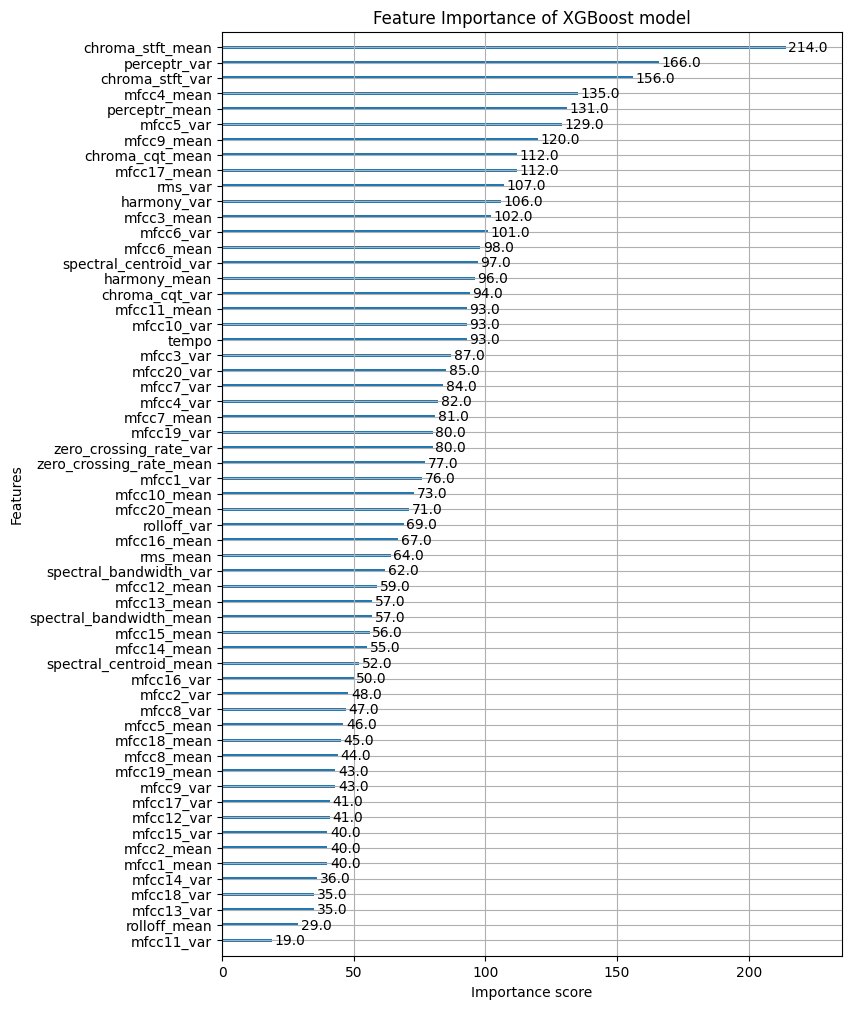

In [69]:
fig, ax = plt.subplots(figsize=(8,12))
from xgboost import plot_importance
plot_importance(clf3, ax=ax, title='Feature Importance of XGBoost model')
plt.show()

- hamornic, percussive time series features have high importance.
- spectral features have relatively low importance.
- mfcc features variance have very low importance.

## without variance features

- excluding variances
- for simplicity only using xgboost with default parameters

In [70]:
feat_names = [col for col in train_data.columns if 'mean' in col] # only mean data

In [71]:
# CHỮA LỖI: Đổi từ 'label' thành 'genre_label' cho khớp với file 30s của bạn
X_train = train_data.loc[:, feat_names]
y_train = pd.Series(pd.Categorical(train_data.loc[:, 'genre_label']).codes)

X_test = test_data.loc[:, feat_names]
y_test = pd.Series(pd.Categorical(test_data.loc[:, 'genre_label']).codes)

print("✅ Đã chia tập Train/Test theo danh sách cột và mã hóa nhãn 30s thành công!")
print(f"Số lượng mẫu - Tập Train: {len(X_train)} bài | Tập Test: {len(X_test)} bài")

✅ Đã chia tập Train/Test theo danh sách cột và mã hóa nhãn 30s thành công!
Số lượng mẫu - Tập Train: 693 bài | Tập Test: 297 bài


In [72]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.5)
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [73]:
y_true = y_test.copy()
y_pred4 = xgb.predict(X_test)

XGB Accuracy:  0.6430976430976431
XGB F1:  0.6487200189841322


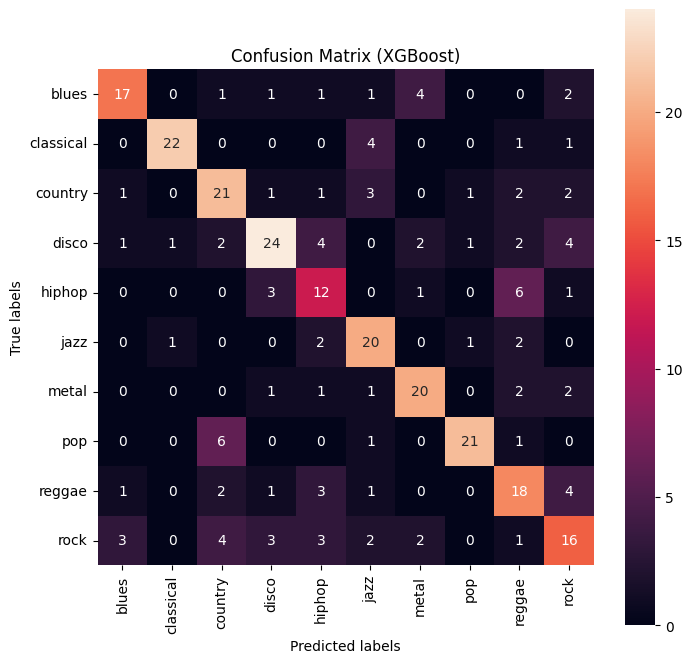

In [74]:
print('XGB Accuracy: ', accuracy_score(y_true, y_pred4))
print('XGB F1: ', f1_score(y_true, y_pred4, average='macro'))

f,ax= plt.subplots(figsize=(8,8))
sns.heatmap(confusion_matrix(y_true, y_pred4), annot=True, square=True, 
            xticklabels=cat_y.categories, yticklabels=cat_y.categories, ax=ax)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (XGBoost)')
plt.show()

- lower scores but not that bad

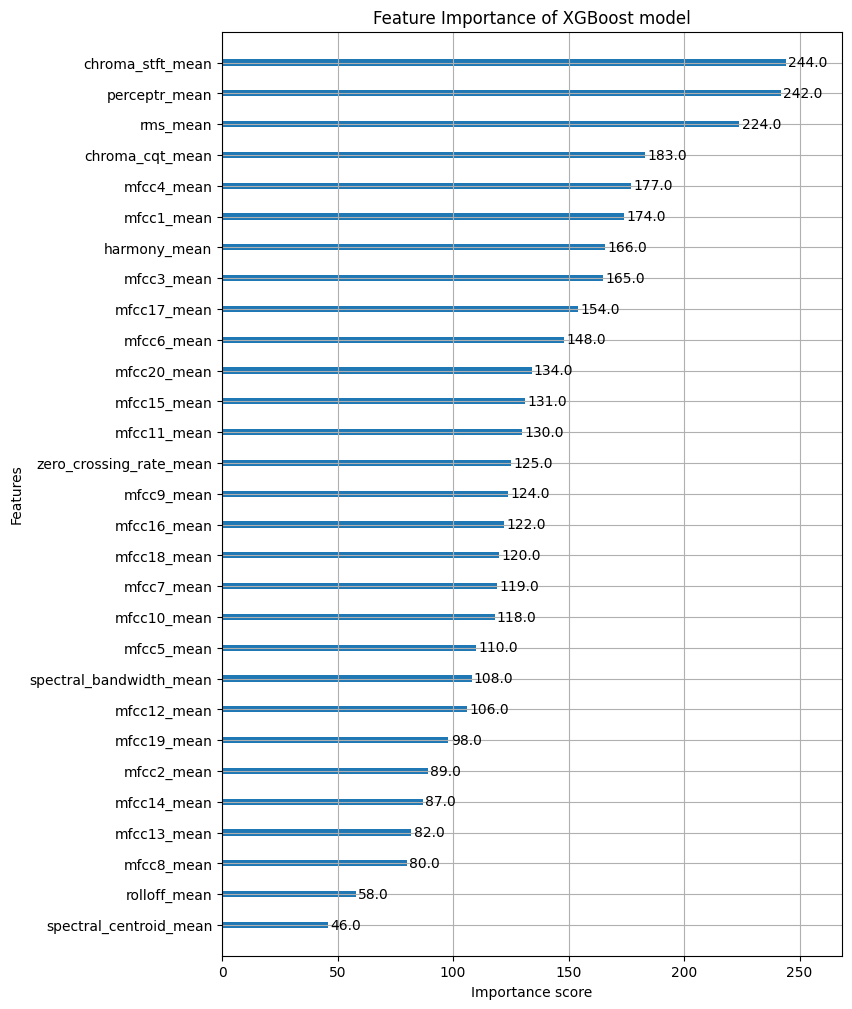

In [75]:
fig, ax = plt.subplots(figsize=(8,12))
plot_importance(xgb, ax=ax, title='Feature Importance of XGBoost model')
plt.show()

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import os

import librosa

import numpy as np

import pandas as pd



# =================================================================

# 1. ĐỊNH NGHĨA HÀM DỰ ĐOÁN (BẮT BUỘC PHẢI CHẠY DÒNG NÀY TRƯỚC)

# =================================================================

def predict_genre_of_file(song_path, model, scaler, categories):

    try:

        # 1. Tải file âm thanh trọn vẹn 30 giây

        y, sr = librosa.load(song_path, duration=30.0)

       

        # 2. Trích xuất toàn bộ các đặc trưng nâng cao

        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)

        rmse = librosa.feature.rms(y=y)

        spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)

        spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)

        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

        zcr = librosa.feature.zero_crossing_rate(y=y)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

       

        harmony_wave = librosa.effects.harmonic(y)

        percussive_wave = librosa.effects.percussive(y)

        chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)

       

        features = {

            'length': len(y),

            'chroma_stft_mean': np.mean(chroma_stft), 'chroma_stft_var': np.var(chroma_stft),

            'rms_mean': np.mean(rmse), 'rms_var': np.var(rmse),

            'spectral_centroid_mean': np.mean(spec_cent), 'spectral_centroid_var': np.var(spec_cent),

            'spectral_bandwidth_mean': np.mean(spec_bw), 'spectral_bandwidth_var': np.var(spec_bw),

            'rolloff_mean': np.mean(rolloff), 'rolloff_var': np.var(rolloff),

            'zero_crossing_rate_mean': np.mean(zcr), 'zero_crossing_rate_var': np.var(zcr),

            'harmony_mean': np.mean(harmony_wave), 'harmony_var': np.var(harmony_wave),

            'perceptr_mean': np.mean(percussive_wave), 'perceptr_var': np.var(percussive_wave),

            'tempo': tempo[0] if isinstance(tempo, (list, np.ndarray)) else tempo,

            'chroma_cqt_mean': np.mean(chroma_cqt), 'chroma_cqt_var': np.var(chroma_cqt)

        }

        for i in range(20):

            features[f'mfcc{i+1}_mean'] = np.mean(mfcc[i])

            features[f'mfcc{i+1}_var'] = np.var(mfcc[i])

           

        df_song = pd.DataFrame([features])

       

        if hasattr(scaler, 'feature_names_in_'):

            model_features = scaler.feature_names_in_

            df_song = df_song.reindex(columns=model_features)

       

        df_song_scaled = scaler.transform(df_song)

        pred_code = model.predict(df_song_scaled)[0]

        return categories[pred_code].upper()

    except Exception as e:

        return f"LỖI (Quá trình trích xuất thất bại: {e})"





# =================================================================

# 2. ĐOẠN QUÉT CẤU TRÚC THƯ MỤC MUSIC_TEST VÀ XUẤT BÁO CÁO

# =================================================================

FOLDER_TEST = "music_test"



if not os.path.exists(FOLDER_TEST):

    print(f"❌ Bạn chưa tạo folder '{FOLDER_TEST}' hoặc để sai vị trí rồi!")

else:

    valid_extensions = ('.wav', '.mp3', '.m4a', '.flac')

   

    testcase_records = []

    stt = 1

    correct_count = 0

    total_files = 0



    print(f"🚀 Hệ thống bắt đầu quét cấu trúc thư mục trong '{FOLDER_TEST}'...")

    print("-" * 90)



    for root, dirs, files in os.walk(FOLDER_TEST):

        music_files = [f for f in files if f.lower().endswith(valid_extensions)]

       

        if not music_files:

            continue

           

        expected_genre = os.path.basename(root).upper()

       

        for file_name in music_files:

            total_files += 1

            full_path = os.path.join(root, file_name)

           

            # Gọi hàm dự đoán vừa định nghĩa ở trên (Hết lỗi NameError)

            prediction = predict_genre_of_file(

                song_path=full_path,

                model=clf1,                  

                scaler=scaler,              

                categories=cat_y.categories  

            )

           

            if expected_genre == prediction:

                status = "PASS ✅"

                correct_count += 1

            else:

                status = "FAIL ❌"

               

            testcase_records.append({

                'STT': stt,

                'Tên File': file_name,

                'Thể loại gốc (Kỳ vọng)': expected_genre,

                'AI Dự đoán (Thực tế)': prediction,

                'Trạng thái': status

            })

            stt += 1



    if total_files == 0:

        print(f"📁 Thư mục '{FOLDER_TEST}' đang trống rỗng, không có file nhạc phù hợp.")

    else:

        df_report = pd.DataFrame(testcase_records)

        pd.set_option('display.max_columns', None)

        pd.set_option('display.width', 1000)

       

        print("\n📊 BẢNG KẾT QUẢ KIỂM THỬ (TESTCASE REPORT):")

        print(df_report.to_string(index=False))

       

        print("-" * 90)

        accuracy = (correct_count / total_files) * 100

        print(f"🎉 Kết quả bộ testcase: ĐÚNG {correct_count}/{total_files} bài (Độ chính xác: {accuracy:.2f}%)")

       

        df_report.to_csv("Bao_cao_Testcase_Phan_Cap.csv", index=False, encoding='utf-8-sig')

        print("💾 File báo cáo đã được lưu thành công!") 

AttributeError: 'OutStream' object has no attribute 'buffer'

In [77]:
!pip install gradio

In [78]:
import os
import librosa
import numpy as np
import pandas as pd
import gradio as gr
import traceback
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ==============================================================================
# 🏋️ BƯỚC 1: TỰ ĐỘNG KHỞI TẠO VÀ HUẤN LUYỆN AI 30S TẠI CHỖ (HÀM TỰ ĐỘNG)
# ==============================================================================
print("⏳ Hệ thống đang kiểm tra và nạp bộ nhớ AI bản 30s... Vui lòng đợi...")

try:
    # Đọc file dữ liệu gốc 30s của bạn
    data_each_song = pd.read_csv('example_features.csv')
    
    # Tách X, y và chữa lỗi lệch tên cột 'label' thành 'genre_label'
    X = data_each_song.drop(columns=['genre_label', 'filename'], errors='ignore')
    labels = data_each_song.loc[:, 'genre_label']
    cat_y = pd.Categorical(labels)
    y = pd.Series(cat_y.codes)
    
    # Chia tập dữ liệu Train/Test tỉ lệ 70/30 theo chuẩn tác giả
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=123, stratify=y)
    
    # Chuẩn hóa dữ liệu bằng StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Huấn luyện mô hình SVM gốc (clf1)
    clf1 = SVC(C=10, gamma=0.01, probability=True) # Bật probability để sau này cần tính tỷ lệ %
    clf1.fit(X_train_scaled, y_train)
    
    # Lưu danh sách thể loại nhạc để App gọi
    categories_list = cat_y.categories
    print("✅ ĐÃ NẠP ĐẠN THÀNH CÔNG! Mô hình SVM 30s đã sẵn sàng chiến đấu.")
except Exception as init_error:
    print(f"❌ Cảnh báo nạp dữ liệu thất bại: {init_error}")
    print("👉 Hãy chắc chắn file 'example_features.csv' đang nằm chung thư mục với file code này.")

# ==============================================================================
# 🎵 BƯỚC 2: HÀM TRÍCH XUẤT ĐẶC TRƯNG VÀ DỰ ĐOÁN FILE PHÁT SINH
# ==============================================================================
def predict_genre_of_file(song_path, model, scaler, categories):
    # 1. Tải file âm thanh trọn vẹn 30 giây
    y, sr = librosa.load(song_path, duration=30.0) 
    
    # 2. Trích xuất toàn bộ các đặc trưng nâng cao
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    rmse = librosa.feature.rms(y=y)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y=y)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
    harmony_wave = librosa.effects.harmonic(y)
    percussive_wave = librosa.effects.percussive(y)
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)
    
    features = {
        'length': len(y),
        'chroma_stft_mean': np.mean(chroma_stft), 'chroma_stft_var': np.var(chroma_stft),
        'rms_mean': np.mean(rmse), 'rms_var': np.var(rmse),
        'spectral_centroid_mean': np.mean(spec_cent), 'spectral_centroid_var': np.var(spec_cent),
        'spectral_bandwidth_mean': np.mean(spec_bw), 'spectral_bandwidth_var': np.var(spec_bw),
        'rolloff_mean': np.mean(rolloff), 'rolloff_var': np.var(rolloff),
        'zero_crossing_rate_mean': np.mean(zcr), 'zero_crossing_rate_var': np.var(zcr),
        'harmony_mean': np.mean(harmony_wave), 'harmony_var': np.var(harmony_wave),
        'perceptr_mean': np.mean(percussive_wave), 'perceptr_var': np.var(percussive_wave),
        'tempo': tempo[0] if isinstance(tempo, (list, np.ndarray)) else tempo,
        'chroma_cqt_mean': np.mean(chroma_cqt), 'chroma_cqt_var': np.var(chroma_cqt)
    }
    for i in range(20):
        features[f'mfcc{i+1}_mean'] = np.mean(mfcc[i])
        features[f'mfcc{i+1}_var'] = np.var(mfcc[i])
        
    # 3. Ép DataFrame bài hát mới nhận ĐÚNG THỨ TỰ CỘT mà bộ chuẩn hóa yêu cầu
    df_song = pd.DataFrame([features])
    if hasattr(scaler, 'feature_names_in_'):
        df_song = df_song.reindex(columns=scaler.feature_names_in_)
    
    # Chuẩn hóa dữ liệu và dự đoán
    df_song_scaled = scaler.transform(df_song)
    pred_code = model.predict(df_song_scaled)[0]
    return categories[pred_code].upper()

# ==============================================================================
# 🚀 BƯỚC 3: HÀM ĐIỀU PHỐI GIAO DIỆN GRADIO
# ==============================================================================
def gradio_predict(audio_file):
    if audio_file is None:
        return "❌ Vui lòng kéo thả hoặc chọn một file nhạc trước khi bấm dự đoán!"
    
    try:
        print(f"📥 Đang xử lý file nhạc: {audio_file}")
        
        # Gọi hàm xử lý lõi với các biến đã được tự động định nghĩa ở Bước 1
        prediction = predict_genre_of_file(
            song_path=audio_file,
            model=clf1,
            scaler=scaler,
            categories=categories_list
        )
        return f"🎵 Dự đoán thể loại: {prediction}"
        
    except Exception as e:
        error_msg = traceback.format_exc()
        print(f"❌ Chi tiết lỗi hệ thống:\n{error_msg}")
        return f"❌ Lỗi trích xuất đặc trưng âm thanh: {str(e)}"

# ==============================================================================
# 🎨 BƯỚC 4: THIẾT KẾ VÀ KHỞI CHẠY GIAO DIỆN WEB
# ==============================================================================
with gr.Blocks(theme=gr.themes.Soft(), title="AI Phân Biệt Thể Loại Nhạc") as demo:
    
    gr.Markdown(
        """
        # 🎵 HỆ THỐNG AI PHÂN BIỆT THỂ LOẠI NHẠC (BẢN 30 GIÂY ĐỒNG BỘ)
        Ứng dụng sử dụng mô hình học máy **SVM** kết hợp với thư viện xử lý âm thanh **Librosa** để phân tích dải tần số âm thanh, nhịp điệu (Tempo) và MFCC nhằm nhận diện thể loại nhạc.
        """
    )
    
    with gr.Row():
        with gr.Column():
            input_audio = gr.Audio(
                label="Tải file nhạc của bạn lên tại đây", 
                type="filepath"
            )
            btn_predict = gr.Button("🔮 Bắt đầu phân tích & Dự đoán", variant="primary")
            
        with gr.Column():
            output_text = gr.Textbox(
                label="🤖 Kết quả từ AI", 
                placeholder="Kết quả dự đoán sẽ hiển thị ở đây...",
                text_align="center"
            )
            
    btn_predict.click(
        fn=gradio_predict, 
        inputs=input_audio, 
        outputs=output_text
    )

# Mở giao diện ứng dụng web
demo.launch(share=False)



⏳ Hệ thống đang kiểm tra và nạp bộ nhớ AI bản 30s... Vui lòng đợi...
✅ ĐÃ NẠP ĐẠN THÀNH CÔNG! Mô hình SVM 30s đã sẵn sàng chiến đấu.


C:\Users\lequo\AppData\Local\Temp\ipykernel_19100\2031761549.py:119: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="AI Phân Biệt Thể Loại Nhạc") as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [79]:
import joblib

# Lưu bộ chuẩn hóa dữ liệu và con AI SVM 30s vào ổ đĩa
joblib.dump(scaler, 'music_scaler.pkl')
joblib.dump(clf1, 'music_svm_model.pkl')

# Lưu luôn cả danh sách các thể loại nhạc (categories) để app.py đọc lại
joblib.dump(cat_y.categories, 'music_categories.pkl')

print("💾 ĐÃ LƯU THÀNH CÔNG 3 FILE: 'music_scaler.pkl', 'music_svm_model.pkl', 'music_categories.pkl'")
print("👉 Giờ bạn có thể tắt Jupyter Notebook và chuyển sang chạy app.py độc lập!")

💾 ĐÃ LƯU THÀNH CÔNG 3 FILE: 'music_scaler.pkl', 'music_svm_model.pkl', 'music_categories.pkl'
👉 Giờ bạn có thể tắt Jupyter Notebook và chuyển sang chạy app.py độc lập!
